# 02 — Customer Segmentation with K-Means

This notebook applies K-Means clustering to the Mall Customers dataset to identify natural customer segments. The optimal number of clusters is selected using the Elbow method and Silhouette analysis, with a feature selection comparison (all features vs. Income + Spending Score only) to highlight the impact on clustering quality. Each resulting segment is then profiled with business-oriented interpretations.

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


Setting up the same dataset path as the previous notebook

In [42]:
DATA_PATH = "../data/raw/Mall_Customers.csv"
df = pd.read_csv(DATA_PATH)

Removing the feature CustomerID because it's useless for clustering or analysis.

In [43]:
df = df.drop(columns=['CustomerID'])
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


Scaling the features using StandardScaler to ensure that none of them dominates the clustering due to their scale.

In [44]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

Searching for the optimal K number for clustering using inertia and silhouette score for analysis.

In [45]:
results = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=9, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    results.append({'K': k, "inertia": kmeans.inertia_, "silhouette_score": score})

results_df = pd.DataFrame(results)
print(results_df)

    K     inertia  silhouette_score
0   2  588.802677          0.251815
1   3  476.787554          0.259513
2   4  386.828426          0.301232
3   5  325.094980          0.317994
4   6  275.195005          0.323675
5   7  236.692879          0.356234
6   8  199.818618          0.387894
7   9  174.188000          0.402721
8  10  152.029834          0.420764


After plotting, the results look rather inconclusive and noisy, without a clear reduction step in inertia or a well-defined peak in the silhouette score that matches the previous analysis in `01_eda.ipynb`. The next step is to remove the Age and Gender features and focus only on the Annual Income and Spending Score features.

In [46]:
df_partial = df.drop(columns=['Gender']).drop(columns=['Age']) 
X_scaled_partial = scaler.fit_transform(df_partial)

results_partial = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=9, n_init=10)
    labels = kmeans.fit_predict(X_scaled_partial)
    score = silhouette_score(X_scaled_partial, labels)
    results_partial.append({'K': k, "inertia": kmeans.inertia_, "silhouette_score": score})

results_df_partial = pd.DataFrame(results_partial)
print(results_df_partial)

    K     inertia  silhouette_score
0   2  269.691012          0.321271
1   3  157.704008          0.466585
2   4  108.921317          0.493907
3   5   65.568408          0.554657
4   6   55.103778          0.538063
5   7   44.911186          0.526345
6   8   37.229355          0.455500
7   9   32.948985          0.455504
8  10   29.090569          0.447628


Same process of searching for the optimal K using inertia and silhouette with the reduced features. This time the results are better than before, with a clear reduction in inertia at K=5, and it's possible to confirm with the silhouette score peak (0.55) that K=5 is the best choice for clustering.

<Axes: xlabel='K', ylabel='inertia'>

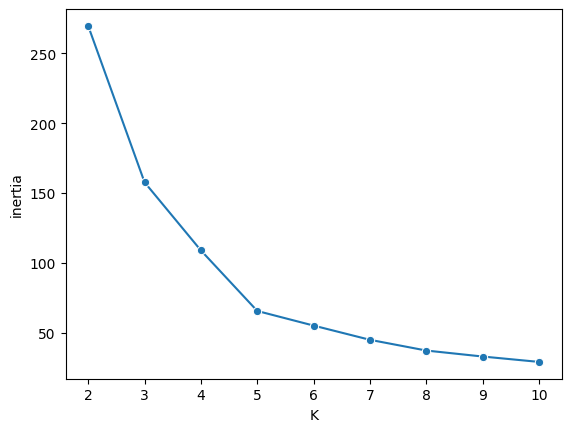

In [47]:
sns.lineplot(data=results_df_partial, x='K', y='inertia', marker='o')

<Axes: xlabel='K', ylabel='silhouette_score'>

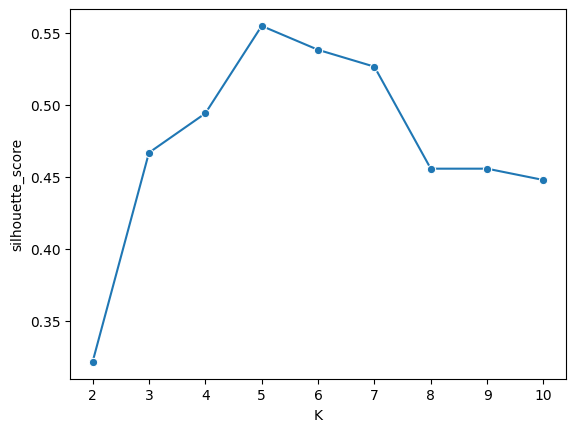

In [48]:
sns.lineplot(data=results_df_partial, x='K', y='silhouette_score', marker='o')

In [49]:
final_model = KMeans(n_clusters=5, random_state=9, n_init=10)
df['cluster'] = final_model.fit_predict(X_scaled_partial)


C:\Users\henri\AppData\Local\Temp\ipykernel_33100\2779660645.py:13: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


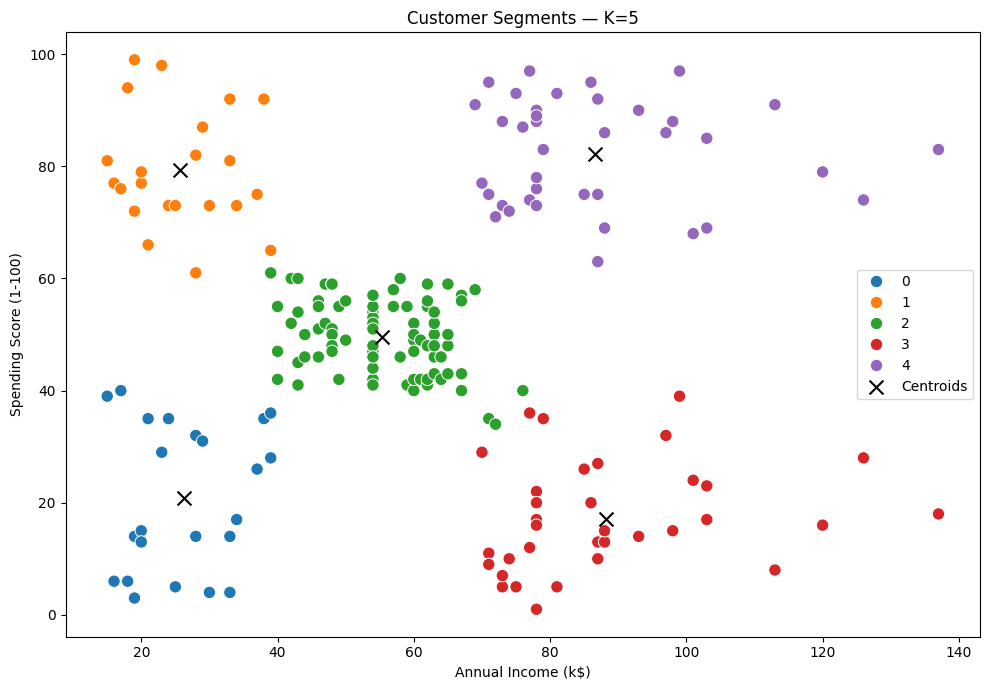

In [50]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='cluster',
    palette='tab10',
    s=80,
)

centroids = scaler.inverse_transform(final_model.cluster_centers_)
plt.scatter(
    centroids[:, 0], centroids[:, 1],
    marker='x', s=100, c='black',
    label='Centroids', edgecolor='white', linewidth=1.5,
)

plt.legend()
plt.title('Customer Segments — K=5')
plt.tight_layout()


As expected from the beginning, we can see a clear division of the clusters. Each cluster represents a very distinct segment of customers that the business (Mall) can target with different strategies.

In [51]:
profile = df.groupby('cluster').mean(numeric_only=True)
print(profile)


           Gender        Age  Annual Income (k$)  Spending Score (1-100)
cluster                                                                 
0        0.608696  45.217391           26.304348               20.913043
1        0.590909  25.272727           25.727273               79.363636
2        0.592593  42.716049           55.296296               49.518519
3        0.457143  41.114286           88.200000               17.114286
4        0.538462  32.692308           86.538462               82.128205


In [54]:
df['cluster'].value_counts()

cluster
2    81
4    39
3    35
0    23
1    22
Name: count, dtype: int64

## Cluster Profiles

Each cluster represents a distinct customer group behavior. I've done a little breakdown of the business problem interpretation:

- Cluster 0 (Bottom Left)
    - "Conservative customers"
    - Low annual income (~26K)
    - Low spending score (~21)
    - Average age: 45 years

- Cluster 1 (Upper Left)
    - "Impulsive customers"
    - Low annual income (~26K)
    - High spending score (~79)
    - Average age: 25 years
    
- Cluster 2 (Center)
    - "Average customers"
    - Average annual income (~55K)
    - Average spending score (~49)
    - Average age: 42 years
    
- Cluster 3 (Bottom Right)
    - "Careful customers"
    - High annual income (~88K)
    - Very Low spending score (~17)
    - Average age: 41 years

- Cluster 4 (Upper Right)
    - "Target customers"
    - High annual income (~87K)
    - High spending score (~82)
    - Average age: 32 years


Some interesting insights:
- The impulsive customers (Cluster 1) which have low income but high spending score, are the youngest group, with an average age of 25 years. This suggests that younger customers may be inclined to spend more possibly due to lifestyle choices or social influences.
- While the overall dataset is 56% female, Cluster 3 (Careful customers/buyers) drops to 45.7% female, a 10-point reversal compared to the base rate. This makes it the only cluster where men are over-represented, suggesting that high-income males display more conservative spending patterns than high-income females in this population.
- A surprising finding is that the Target segment (high income + high spending) is also among the youngest (avg age 33). This contradicts the common assumption that wealth and high spending are tied to middle-aged executives. Possible profiles: young professionals in tech/finance, dual-income young couples, or early career success cases.
- The Average cluster (2) is the largest segment, representing the bulk of regular customers, they provide volume revenue.
- The Careful Buyers cluster (17.5%) is structurally significant: they have the highest income ($88k average) but the lowest spending ($17 score). Converting even a fraction of them into more active spenders would have major revenue impact, given their financial capacity.



> **Note**: gender comparisons reference the dataset's base rate of 56% 
> female. Cluster percentages are interpreted as **deviations** from this 
> baseline rather than as absolute majorities, to avoid spurious 
> demographic claims driven by the underlying class imbalance.

In [52]:
import joblib
joblib.dump(final_model, '../models/kmeans_k5.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
print("Models saved to ../models/")


Models saved to ../models/
